# Waffle Chart - Data Analysis Notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the CSV file 'number_of_reported_fatalities_by_country-year_as-of-09Jan2026.csv' into a DataFrame
path_fatalities = "../data/ACLED/number_of_reported_fatalities_by_country-year_as-of-09Jan2026.CSV"
df = pd.read_csv(path_fatalities, encoding='utf-8', sep=';')

In [3]:
# Display the first few rows of the DataFrame for debugging
print(df.head())

       COUNTRY  YEAR  FATALITIES
0  Afghanistan  2017       36360
1  Afghanistan  2018       42991
2  Afghanistan  2019       41419
3  Afghanistan  2020       30977
4  Afghanistan  2021       42425


## Extracting data useful for the Waffle Chart

### First Waffle Chart: Conflict vs No Conflict Countries in 2025

In [4]:
# Showing statistics for fatalities in 2025
df[(df['YEAR'] == 2025)]['FATALITIES'].describe()

count      205.000000
mean      1156.326829
std       6018.326166
min          0.000000
25%          0.000000
50%          2.000000
75%         81.000000
max      78347.000000
Name: FATALITIES, dtype: float64

Since more than half of the countries present in the list have less than 2 fatalities, we say that a country is involved in a conflict if it has at least 10 fatalities associated.

In [5]:
# Number of distinct countries involved in conflicts in 2025 (meaning countries with reported fatalities > 10)
num_countries_2025 = df[(df['YEAR'] == 2025) & (df['FATALITIES'] > 10)]['COUNTRY'].nunique()
print(f'Number of distinct countries involved in conflicts in 2025: {num_countries_2025}')

Number of distinct countries involved in conflicts in 2025: 73


In [6]:
# Total number of distinct countries present in the ACLED dataset
total_countries = df['COUNTRY'].nunique()
print(f'Total number of distinct countries: {total_countries}')

Total number of distinct countries: 245


In [7]:
# Calculate the percentage of countries involved in conflicts in 2025
percentage_in_conflict_2025 = (num_countries_2025 / total_countries) * 100
print(f'Percentage of countries involved in conflicts in 2025: {percentage_in_conflict_2025:.2f}%')

Percentage of countries involved in conflicts in 2025: 29.80%


In [8]:
# Round the percentage to the nearest whole number
rounded_percentage = round(percentage_in_conflict_2025)
print(f'Rounded percentage: {rounded_percentage}%')

Rounded percentage: 30%


In [9]:
# Prepare data for Waffle Chart and save it to csv
waffle_data = [
    {'category': 'not_in_conflict', 'value': 100 - rounded_percentage, 'absolute': total_countries - num_countries_2025},
    {'category': 'in_conflict', 'value': rounded_percentage, 'absolute': num_countries_2025},
]

waffle_df = pd.DataFrame(waffle_data)
waffle_df.head()

,category,value,absolute
0,not_in_conflict,70,172
1,in_conflict,30,73


In [ ]:
# Save the waffle chart data to a CSV file
# waffle_df.to_csv('../data/processed/waffle_chart_data.csv', index=False)

### Second Waffle Chart: splitting the conflicting countries by their fatality count

We first need a way to group the countries in clusters by their fatalities. So we take a look at the values in the FATALITIES column (for the year 2025 and with at least 10 fatalities)

In [11]:
df_2025 = df[(df['YEAR'] == 2025) & (df['FATALITIES'] >= 10)].copy()
df_2025['FATALITIES'].describe()

count       77.000000
mean      3076.493506
std       9551.965508
min         10.000000
25%         42.000000
50%        282.000000
75%       1932.000000
max      78347.000000
Name: FATALITIES, dtype: float64

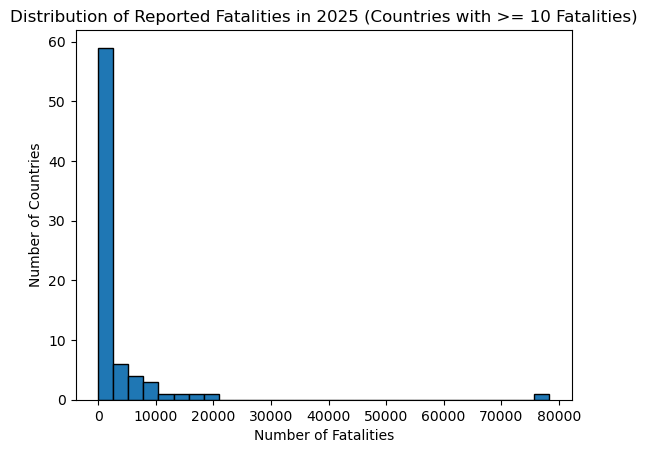

In [12]:
# Showing the fatalities distribution as an histogram
plt.hist(df_2025['FATALITIES'], bins=30, edgecolor='black')
plt.title('Distribution of Reported Fatalities in 2025 (Countries with >= 10 Fatalities)')
plt.xlabel('Number of Fatalities')
plt.ylabel('Number of Countries')
plt.show()

We immediately show that in order to make balanced groups for a meaningful visualization we need to cluster the countries following almost a logarithmic scale.

So we will make 3 bins. The first one will have fatality values between 11 and 100, the second one between 101 and 1000, and the last one will have all the countries with more than 1000 fatalities.

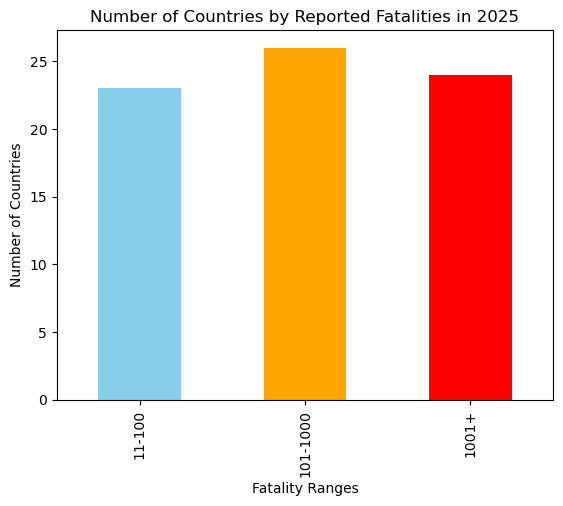

In [13]:
# Making a bar chart visualization of the fatalities distribution with 3 bins
# Bins: 11-100, 101-1000, 1001+
# Showing it in matplotlib

bins = [11, 101, 1001, float('inf')]
labels = ['11-100', '101-1000', '1001+']
fatalities_grouped = pd.cut(df_2025['FATALITIES'], bins=bins, labels=labels, right=False)
fatalities_counts = fatalities_grouped.value_counts().sort_index()
fatalities_counts.plot(kind='bar', color=['skyblue', 'orange', 'red'])
plt.title('Number of Countries by Reported Fatalities in 2025')
plt.xlabel('Fatality Ranges')
plt.ylabel('Number of Countries')
plt.show()

In [14]:
labels = ['Low', 'Medium', 'High']
df_2025['FATALITY_CLUSTER'] = pd.cut(df_2025['FATALITIES'], bins=bins, labels=labels, right=False)
counts = df_2025['FATALITY_CLUSTER'].value_counts()
print(counts)

FATALITY_CLUSTER
Medium    26
High      24
Low       23
Name: count, dtype: int64


In [15]:
# Create a DataFrame with 'Category' in {'not_in_conflict', 'low', 'medium', 'high'} 
# and their corresponding values in percentages rounded to whole numbers 
# so that they sum to 100 and where 'not_in_conflict' is 70

cluster_counts = counts.reindex(labels, fill_value=0)
cluster_percentages = (cluster_counts / total_countries) * 100
print(cluster_counts)
print(cluster_percentages)

FATALITY_CLUSTER
Low       23
Medium    26
High      24
Name: count, dtype: int64
FATALITY_CLUSTER
Low        9.387755
Medium    10.612245
High       9.795918
Name: count, dtype: float64


In [16]:
rounded_cluster_percentages = cluster_percentages.round().astype(int)
rounded_not_in_conflict = round((total_countries - num_countries_2025) / total_countries * 100)
waffle_data_detailed = [
    {'category': 'not_in_conflict', 'value': rounded_not_in_conflict, 'absolute': total_countries - num_countries_2025},
    {'category': 'low', 'value': rounded_cluster_percentages['Low'], 'absolute': cluster_counts['Low']},
    {'category': 'medium', 'value': rounded_cluster_percentages['Medium'], 'absolute': cluster_counts['Medium']},
    {'category': 'high', 'value': rounded_cluster_percentages['High'], 'absolute': cluster_counts['High']},
]

# if the sum is not 100, adjust the category with the highest value
total_value = sum(item['value'] for item in waffle_data_detailed)
if total_value != 100:
    difference = 100 - total_value
    max_item = max(waffle_data_detailed, key=lambda x: x['value'])
    max_item['value'] += difference

waffle_df_detailed = pd.DataFrame(waffle_data_detailed)
waffle_df_detailed.head()

,category,value,absolute
0,not_in_conflict,70,172
1,low,9,23
2,medium,11,26
3,high,10,24


In [17]:
waffle_df_detailed.to_csv('../data/processed/waffle_chart_data.csv', index=False)